<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2023-01-01">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization Lab**


Estimated time needed: **45 to 60** minutes


In this assignment you will be focusing on the visualization of data.

The data set will be presented to you in the form of a RDBMS.

You will have to use SQL queries to extract the data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


<hr>


## Demo: How to work with database


Download database file.


Connect to the database.


In [3]:
!curl -O https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/Capstone_edX/Module%204/master.db

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 8488k  100 8488k    0     0  4311k      0  0:00:01  0:00:01 --:--:-- 4310k


In [4]:
import sqlite3
import pandas as pd
conn = sqlite3.connect('master.db')
cur = conn.cursor()
QUERY = "SELECT * FROM master"
# the read_sql_query runs the sql query and returns the data as a dataframe
df = pd.read_sql_query(QUERY,conn)
print(df.head())

   Respondent                      MainBranch Hobbyist  Age Age1stCode  \
0           1  I am a developer by profession      Yes   22         14   
1           2  I am a developer by profession      Yes   39         14   
2           3  I am a developer by profession       No   32         14   
3           4  I am a developer by profession      Yes   53         10   
4           5  I am a developer by profession      Yes   25         12   

  CompFreq  CompTotal  ConvertedComp         Country          CurrencyDesc  \
0   Yearly      25000          32315  United Kingdom        Pound sterling   
1  Monthly       4900          63564         Belgium         European Euro   
2   Yearly     130000         130000   United States  United States dollar   
3   Yearly      58000          74970  United Kingdom        Pound sterling   
4   Yearly     550000         594539          France         European Euro   

   ...                      SOVisitFreq                  SurveyEase  \
0  ...         

Import pandas module.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Demo: How to run an sql query


In [6]:
# print how many rows are there in the table named 'master'
QUERY = """
SELECT COUNT(*)
FROM master
"""

# the read_sql_query runs the sql query and returns the data as a dataframe
df1 = pd.read_sql_query(QUERY,conn)
df1.head()

,COUNT(*)
0,4387


## Demo: How to list all tables


In [7]:
# print all the tables names in the database
QUERY = """
SELECT name as Table_Name FROM
sqlite_master WHERE
type = 'table'
"""
# the read_sql_query runs the sql query and returns the data as a dataframe
pd.read_sql_query(QUERY,conn)


,Table_Name
0,MASTER


## Demo: How to run a group by query


# Hands-on Lab


## Visualizing distribution of data


### Histograms


Plot a histogram of `ConvertedComp.`


(array([4.094e+03, 1.060e+02, 3.600e+01, 2.900e+01, 2.200e+01, 3.900e+01,
        3.000e+00, 6.000e+00, 4.000e+00, 4.800e+01]),
 array([      0.,  200000.,  400000.,  600000.,  800000., 1000000.,
        1200000., 1400000., 1600000., 1800000., 2000000.]),
 <BarContainer object of 10 artists>)

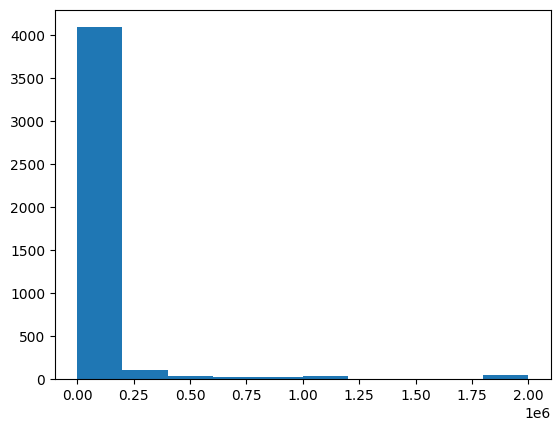

In [20]:
# your code goes here
plt.hist(df['ConvertedComp'])

### Box Plots


Plot a box plot of `Age.`


<Axes: >

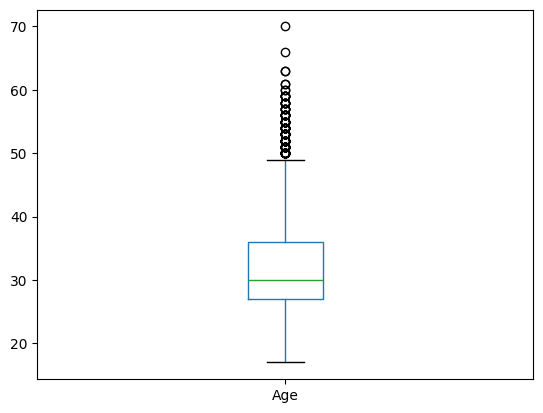

In [17]:
# your code goes here

df.boxplot(column =['Age'],grid=False) 

## Visualizing relationships in data


### Scatter Plots


Create a scatter plot of `Age` and `WorkWeekHrs.`


<Axes: xlabel='Age', ylabel='WorkWeekHrs'>

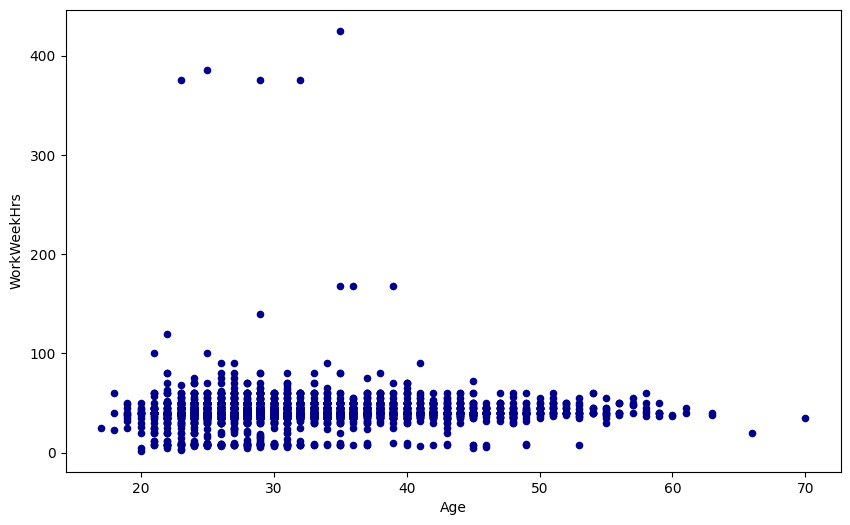

In [21]:
# your code goes here
df.plot(kind='scatter', x='Age', y='WorkWeekHrs', figsize=(10, 6), color='darkblue')


### Bubble Plots


Create a bubble plot of `WorkWeekHrs` and `Age`, use `Age` column as bubble size.

##### Hint: Use plotly.express to create a bubble chart


In [22]:
import sys

!{sys.executable} -m pip install plotly


import plotly.express as px
fig = px.scatter(df, x="WorkWeekHrs", y="Age",
         size="Age", log_x=True, size_max=10)
fig.show()

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 9.9 MB 2.5 MB/s eta 0:00:01
     |████████████████████████████████| 451 kB 11.3 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


## Visualizing composition of data


### Pie Charts


Create a pie chart of the top 5 Country that respondents filled the survey . Display percentages of each database on the pie chart. 


<Axes: ylabel='count'>

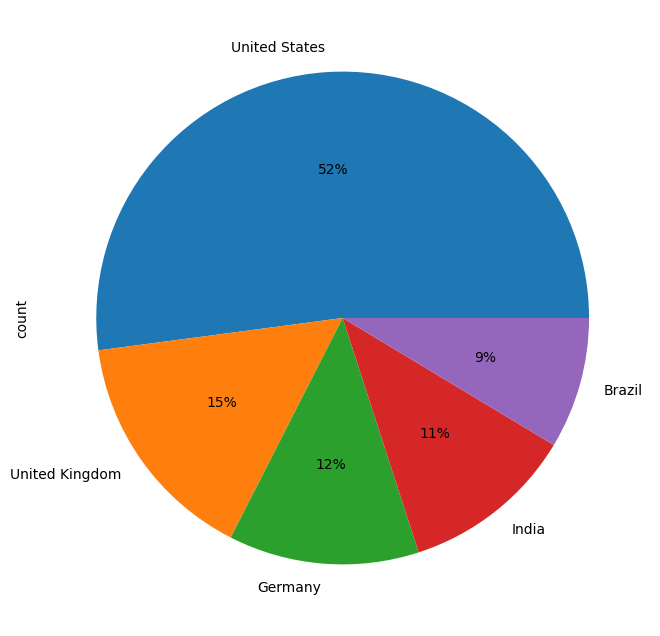

In [23]:
# your code goes here
df_pie = df['Country'].value_counts()
df_pie=df_pie.head(5)
df_pie.plot(kind='pie', figsize=(8,8), autopct='%1.0f%%')

## Visualizing comparison of data


### Line Chart


Draw distribution plot for ConverteComp and plot the median

##### Hint: Use seaborn library for distribution plot


/var/folders/sn/l0yz_8z96vz614m4x2rcs9m40000gn/T/ipykernel_72567/3085787239.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["ConvertedComp"])


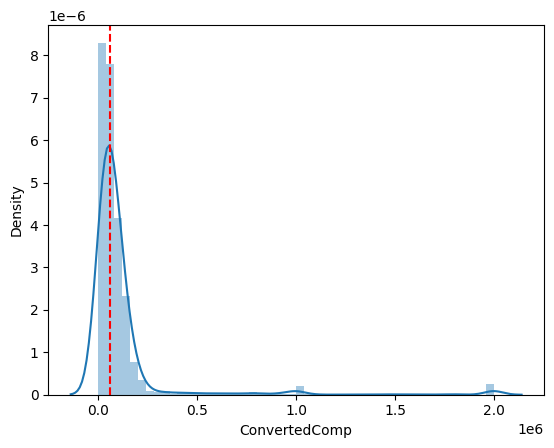

In [28]:
# your code goes here
import seaborn as sns
median=df['ConvertedComp'].median()
sns.distplot(df["ConvertedComp"])
plt.axvline(median, color='r', linestyle='--', label=f"Median = {median:,.0f}")

### Bar Chart


Create a horizontal bar chart using column `MainBranch.`


<Axes: ylabel='MainBranch'>

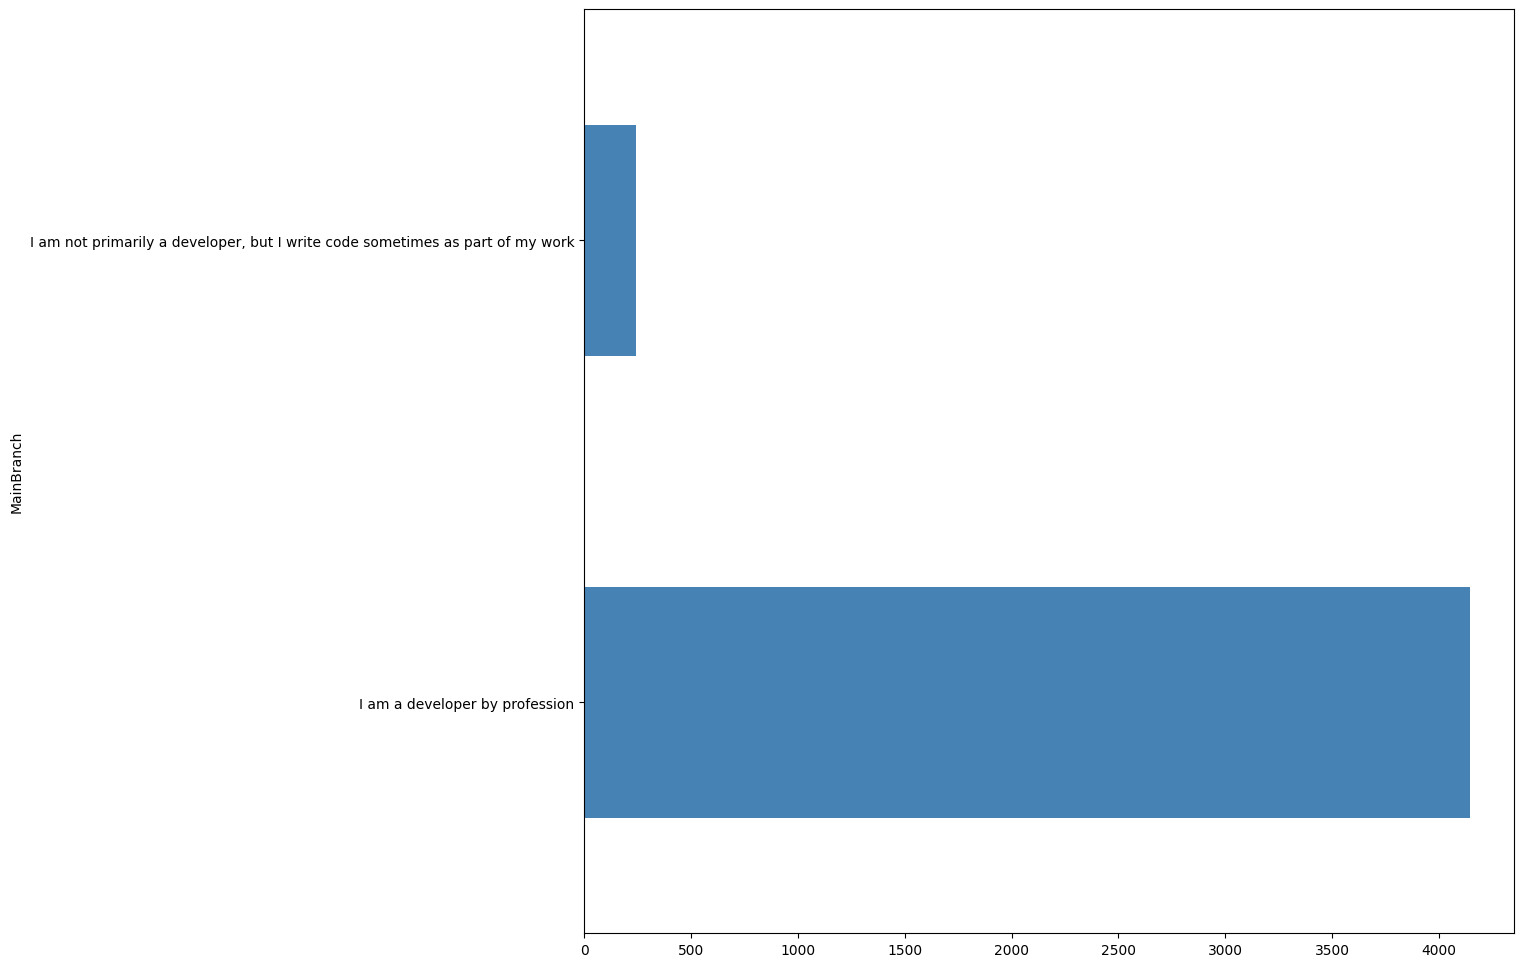

In [25]:
# your code goes here
df_mbranch = df['MainBranch'].value_counts()
df_mbranch
df_mbranch.plot(kind='barh', figsize=(12, 12), color='steelblue')


Close the database connection.


In [26]:
conn.close()